In [7]:
import matplotlib.pyplot as plt
import os 
import pandas as pd
import seaborn as sns

# Load Data

In [3]:
# Since the dataset has no header and therefore no names for the columns, we define them here  
index_names = ['engine_number', 'time_cycle']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

In [6]:
# Load the file
df = pd.read_csv('../data/raw/train_FD001.txt', sep=r'\s+', header=None, names=col_names)

# Dataset Overview

In [23]:
df.shape

(20631, 27)

The dataset consists of 20,631 rows and 27 columns, representing a moderately large benchmark dataset that is well-suited for classical machine learning methods. 

In [33]:
df.head()

,engine_number,time_cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [34]:
df.tail()

,engine_number,time_cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,519.30,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522


The rows in the dataset are already ordered by engine number and time cycle. Additionally, the dataset consists of exactly 100 engines.


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   engine_number  20631 non-null  int64  
 1   time_cycle     20631 non-null  int64  
 2   setting_1      20631 non-null  float64
 3   setting_2      20631 non-null  float64
 4   setting_3      20631 non-null  float64
 5   sensor_1       20631 non-null  float64
 6   sensor_2       20631 non-null  float64
 7   sensor_3       20631 non-null  float64
 8   sensor_4       20631 non-null  float64
 9   sensor_5       20631 non-null  float64
 10  sensor_6       20631 non-null  float64
 11  sensor_7       20631 non-null  float64
 12  sensor_8       20631 non-null  float64
 13  sensor_9       20631 non-null  float64
 14  sensor_10      20631 non-null  float64
 15  sensor_11      20631 non-null  float64
 16  sensor_12      20631 non-null  float64
 17  sensor_13      20631 non-null  float64
 18  sensor_14      20

In [26]:
df['sensor_17']

0        392
1        392
2        390
3        392
4        393
        ... 
20626    397
20627    395
20628    398
20629    395
20630    396
Name: sensor_17, Length: 20631, dtype: int64

In [25]:
df['sensor_18']

0        2388
1        2388
2        2388
3        2388
4        2388
         ... 
20626    2388
20627    2388
20628    2388
20629    2388
20630    2388
Name: sensor_18, Length: 20631, dtype: int64

In [29]:
df['sensor_18'].nunique()

1

All columns in the dataset are numerical and contain no non-numeric (string) features. Four columns have the data type `int64` instead of `float64`. For `engine_number` and `time_cycle`, this is expected and trivial.

However, `sensor_17` and `sensor_18` are also stored as `int64`. For `sensor_17`, we observe an increasing trend in its values; therefore, we keep this column unchanged. In contrast, `sensor_18` consistently shows the value 2388 across all time cycles, indicating a constant sensor signal that is not informative and may be misleading for downstream models.

Since similar issues may exist in other sensors, we proceed by analyzing engine lifecycles in the next step.

Since our goal is to predict the remaining useful life (RUL) and this target variable is not yet included in the dataset, we need to construct it manually in a subsequent step.

# Engine Lifecycle Analysis 

In [36]:
# How many engines are there?
num_engines = df['engine_number'].nunique()
num_engines

100

In [37]:
# How long does each engine run?
engine_lifespans =df.groupby('engine_number')['time_cycle'].max()

print("\n --- Lifespan of the engines (cycles) --- \n")

engine_lifespans.describe()


 --- Lifespan of the engines (cycles) --- 



count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_cycle, dtype: float64

We observe that the engines operate within a range of 128 to 362 cycles, with a mean of approximately 206 cycles.

In [12]:
# Available sensors
# Some sensors contain constant values and therefore provide no meaningful information; we identify those that exhibit any variation.
sensor_cols = [col for col in df.columns if 'sensor_' in col]
unique_counts = df[sensor_cols].nunique()
unique_counts

sensor_1        1
sensor_2      310
sensor_3     3012
sensor_4     4051
sensor_5        1
sensor_6        2
sensor_7      513
sensor_8       53
sensor_9     6403
sensor_10       1
sensor_11     159
sensor_12     427
sensor_13      56
sensor_14    6078
sensor_15    1918
sensor_16       1
sensor_17      13
sensor_18       1
sensor_19       1
sensor_20     120
sensor_21    4745
dtype: int64

In [13]:
active_sensors = unique_counts[unique_counts > 1].index.to_list()
active_sensors

['sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_17',
 'sensor_20',
 'sensor_21']

In [9]:
constant_sensors = unique_counts[unique_counts == 1].index.to_list()
constant_sensors

['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

In [10]:
print(f"\nActive Sensors ({len(active_sensors)}): {active_sensors}")



Active Sensors (15): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [30]:
print(f"\nConstant Sensors ({len(constant_sensors)}): {constant_sensors}")



Constant Sensors (6): ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


As expected, the dataset contains several constant and uninformative sensors, six in total. We will exclude these from further analysis and will likely remove them from the dataset in a later step.

## What does a failure look like?

We analyze sensor values during the five cycles prior to failure (RUL ≈ 0).

In [19]:
print("\n--- sensor values prior to failure (last 5 cycles (RUL <= 5)) ---\n")
faulty_means =df.groupby('engine_number').tail(5)[active_sensors].mean()
faulty_means


--- sensor values prior to failure (last 5 cycles (RUL <= 5)) ---



sensor_2      643.670000
sensor_3     1602.289060
sensor_4     1428.926760
sensor_6       21.610000
sensor_7      551.494840
sensor_8     2388.232120
sensor_9     9097.991980
sensor_11      48.142200
sensor_12     519.809180
sensor_13    2388.233500
sensor_14    8166.866480
sensor_15       8.520405
sensor_17     396.240000
sensor_20      38.446000
sensor_21      23.069989
dtype: float64

In [20]:
# comparison "healthy" vs "faulty"
healthy_means = df[df['time_cycle'] <= 10][active_sensors].mean()

In [21]:
comparison_df = pd.DataFrame({
    'Healthy Start': healthy_means,
    'Immediately pre-failure': faulty_means
})

In [22]:
import numpy as np
comparison_df['Direction of Change'] = np.where(
    comparison_df['Immediately pre-failure'] > comparison_df['Healthy Start'], 
    'Increase', 
    'Decrease' 
)

In [23]:
comparison_df['% Change'] = ((comparison_df['Immediately pre-failure'] - comparison_df['Healthy Start']) / comparison_df['Healthy Start'] * 100).round(2)

In [24]:
comparison_df.sort_values(by='% Change', ascending=False)

,Healthy Start,Immediately pre-failure,Direction of Change,% Change
sensor_4,1402.645380,1428.926760,Increase,1.87
sensor_11,47.349970,48.142200,Increase,1.67
sensor_15,8.418042,8.520405,Increase,1.22
sensor_17,392.253000,396.240000,Increase,1.02
sensor_3,1586.800870,1602.289060,Increase,0.98
sensor_9,9055.985110,9097.991980,Increase,0.46
sensor_14,8137.325380,8166.866480,Increase,0.36
sensor_2,642.373610,643.670000,Increase,0.20
sensor_13,2388.055690,2388.233500,Increase,0.01
sensor_8,2388.057610,2388.232120,Increase,0.01


In [25]:
comparison_df['Direction of Change'].value_counts()

Direction of Change
Increase    11
Decrease     4
Name: count, dtype: int64

Eleven of the active sensors show a long-term increase in values, while the remaining sensors show an overall decrease.

We observe that most engines show increased sensor values compared to their healthy baseline prior to failure. Additionally, the percentage change is generally very small across all sensors (approximately 1.86 to -1.25 percent), indicating that only minor variations in sensor readings can precede a failure.

# Sensor Visualization

## Data-Driven Hypothesis & Selection for Visualization

Before blindly plotting all 21 sensors, we leverage the empirical evidence from `comparison_df`. The percentage changes between the healthy baseline state and the cycles shortly before failure reveal which sensors best reflect the physical degradation of the machine.

We deliberately select four sensors to examine four distinct behavioral patterns of the system:

**sensor_4 (+1.86%) – Primary Indicator (Strong Increase)**  
Expectation: As this sensor shows the strongest percentage increase, we expect a steadily rising curve over time. It should resemble a “fever curve,” clearly indicating progressive wear.

**sensor_21 (-1.25%) – Counter Indicator (Strong Decrease)**  
Expectation: This sensor exhibits one of the strongest declines. We plot it as the inverse counterpart to sensor_4. As engine wear increases (sensor_4 rises), we expect this signal to decrease, potentially reflecting reduced pressure or flow.

**sensor_15 (+1.21%) – Accelerated Wear Indicator**  
Expectation: This sensor also shows a strong increase. We aim to determine whether its trajectory is linear or whether it remains stable for most of the lifetime and then rises sharply in an exponential-like pattern shortly before failure.

**sensor_6 (0.00%) – Control Case (Baseline Reference)**  
Expectation: According to the data, this sensor does not change at all. We include it as a control to validate our reasoning. A perfectly flat line would confirm that this sensor carries no predictive information.

By combining a strong increase, a strong decrease, and a flat baseline, we test whether the physical degradation patterns remain stable and predictable across the full lifecycle of Engine 1.

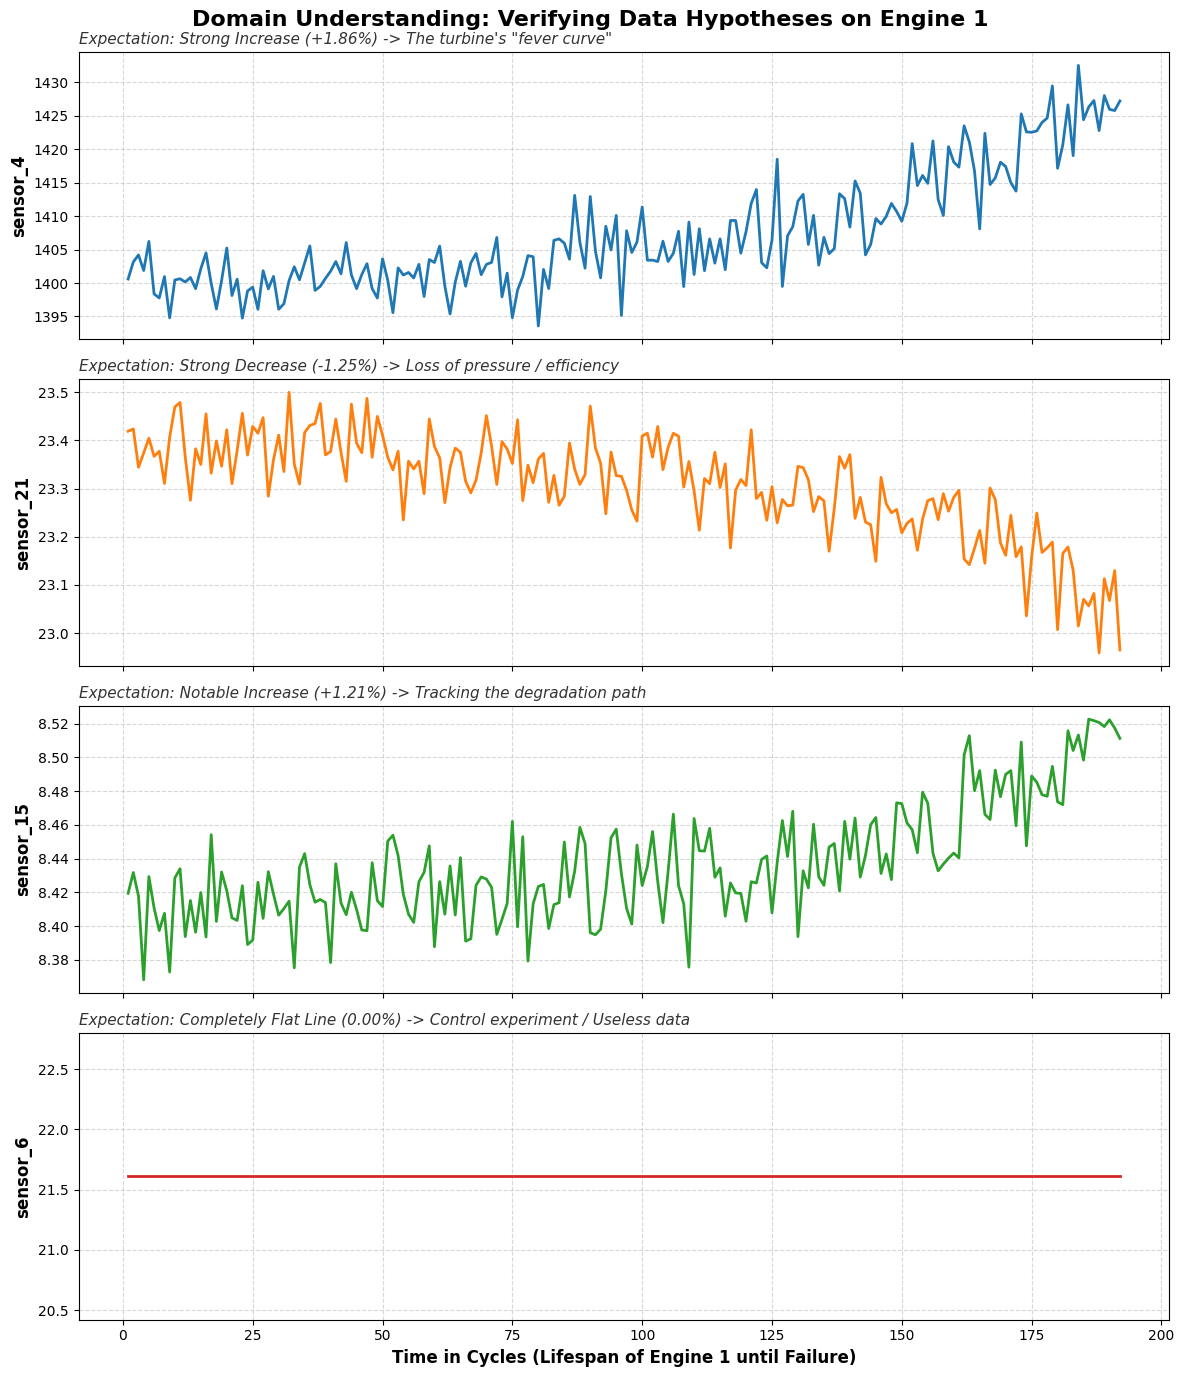

In [47]:
# The 4 purposefully selected sensors from the comparison_df
target_sensors = ['sensor_4', 'sensor_21', 'sensor_15', 'sensor_6']

# The matching hypotheses used as subtitles for the plots
hypotheses = {
    'sensor_4': 'Expectation: Strong Increase (+1.86%) -> The turbine\'s "fever curve"',
    'sensor_21': 'Expectation: Strong Decrease (-1.25%) -> Loss of pressure / efficiency',
    'sensor_15': 'Expectation: Notable Increase (+1.21%) -> Tracking the degradation path',
    'sensor_6': 'Expectation: Completely Flat Line (0.00%) -> Control experiment / Useless data'
}

# Prepare subplots (4 rows, 1 column)
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 14), sharex=True)
fig.suptitle('Domain Understanding: Verifying Data Hypotheses on Engine 1', fontsize=16, fontweight='bold', y=0.98)

# Filter data for Engine 1
engine_1 = df[df['engine_number'] == 1]

for i, sensor in enumerate(target_sensors):
    ax = axes[i]
    # Plot the curve (each sensor gets its own unique color)
    ax.plot(engine_1['time_cycle'], engine_1[sensor], color=f'C{i}', linewidth=2, label='Measured Values')
    
    # Sensor name on the left and the data-driven expectation as a subtitle on top
    ax.set_ylabel(sensor, fontsize=12, fontweight='bold')
    ax.set_title(hypotheses[sensor], fontsize=11, loc='left', color='#333333', style='italic')
    
    # Visual grid for easier scanning
    ax.grid(True, linestyle='--', alpha=0.5)

# X-axis label at the very bottom plot
axes[-1].set_xlabel('Time in Cycles (Lifespan of Engine 1 until Failure)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()





As expected, the first three curves resemble typical “fever curves,” meaning their trajectories continuously fluctuate over time and exhibit irregular, jagged patterns characterized by sharp peaks and deep troughs, indicating highly variable sensor behavior.

Additionally, the control case (`sensor_6`) appears as a perfectly flat line throughout the entire lifecycle, confirming our expectations and validating the previous analysis.

Furthermore, both `sensor_4` and `sensor_15` fluctuate continuously but remain relatively stable throughout a substantial portion of their operational lifetime before beginning to increase as the engine approaches failure. Despite the persistent fluctuations, the upward trend appears predominantly linear rather than strongly exponential.

Similarly, `sensor_21` also fluctuates continuously while remaining stable for approximately 85% of its lifetime before showing a clearly observable and sharper decline near the end of the lifecycle, indicating imminent failure. Unlike the previous sensors, the decrease no longer appears strictly linear.

To filter out high-frequency noise and expose the underlying degradation trends, it appears highly beneficial to create rolling-mean features for modeling purposes, thereby revealing the true trajectory more clearly.

Additionally, models such as LSTMs or Random Forests may struggle to map highly erratic and jagged input signals to a comparatively smooth Remaining Useful Life (RUL) target.

# Missing Values & Data Quality

In [18]:
df.isna().sum()

unit_number    0
time_cycle     0
setting_1      0
setting_2      0
setting_3      0
sensor_1       0
sensor_2       0
sensor_3       0
sensor_4       0
sensor_5       0
sensor_6       0
sensor_7       0
sensor_8       0
sensor_9       0
sensor_10      0
sensor_11      0
sensor_12      0
sensor_13      0
sensor_14      0
sensor_15      0
sensor_16      0
sensor_17      0
sensor_18      0
sensor_19      0
sensor_20      0
sensor_21      0
RUL            0
dtype: int64

We observe that the dataset contains no missing values, which is beneficial since no special missing-value handling techniques are required.

# Summary of Initial Insights

We have now completed the initial exploration of the dataset and identified the following key insights:

- The dataset is well-maintained, contains no missing values, and has no string-typed columns.
- The engines operate within a range of 128 to 362 cycles, with a mean of approximately 206 cycles. This indicates that engine lifespans vary significantly within the training dataset.
- There are 21 sensors in total, of which 6 are constant and 15 are active. The constant sensors are: `sensor_1`, `sensor_5`, `sensor_10`, `sensor_16`, `sensor_18`, and `sensor_19`. As mentioned, these columns will be removed later as they contain no useful information.
- For most active sensors, we observe a clear trend indicating engine degradation. Only for `sensor_14`, `sensor_8`, and `sensor_6` is the percent change between start and end below approximately 0.2%.
- Eleven of the active sensors show a long-term increase in values, while the remaining sensors show an overall decrease.
- All active sensor time series resemble typical “fever curves,” meaning their trajectories continuously fluctuate over time and exhibit irregular, jagged patterns with sharp peaks and deep troughs, indicating highly variable sensor behavior. This suggests that the data contains realistic noise and further highlights the necessity of feature engineering (e.g., rolling mean features) before modeling.
- Our example plots of `sensor_4`, `sensor_15`, and `sensor_21` for engine 1 over time support the hypothesis that sensor behavior is typically characterized by an initial phase of relative stability (with noise), followed by a clear shift during the degradation phase, where values begin to increase or decrease more noticeably.

In [2]:
os.makedirs("../data/processed", exist_ok=True)

df.to_parquet("../data/processed/fd001_clean.parquet", index=False)

NameError: name 'os' is not defined